# Online Review Sentiment Analysis (Flipkart / Twitter)
**Tamim Ahmed · ID 905253015 · United International University, School of Business and Economics**

Three-class sentiment analysis (positive / neutral / negative) of a **synthetic** dataset of 2,000 marketplace
reviews and tweets that I generated for this project (`src/generate_dataset.py`).
The notebook follows the four deliverables of the assignment brief. All heavy lifting lives in
`src/sentiment_pipeline.py` and `src/text_utils.py`; this notebook calls those functions step by step and
shows the results.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Image, display
import sentiment_pipeline as sp
from text_utils import clean_text, clean_text_demo

pd.set_option("display.max_colwidth", 120)
sp.TAB.mkdir(parents=True, exist_ok=True)
fig = lambda name: display(Image(filename=str(sp.FIG / name), width=820))

## 0. The dataset
If `data/synthetic_reviews.csv` is missing, regenerate it with `python src/generate_dataset.py`
(seeded with my student ID, so it is exactly reproducible).

In [2]:
df = sp.load_data()
print(df.shape)
df.sample(6, random_state=1)[["review_text", "product", "source", "sentiment", "rating"]]

(2000, 12)


,review_text,product,source,sentiment,rating
674,Second AirBeat Earbuds I have bought from this seller. Replacement arrived within three days.,AirBeat Earbuds,Flipkart,positive,5
1699,Bought this PowerCore Power Bank after reading the reviews. The charging speed is about what you would expect. Three...,PowerCore Power Bank,Flipkart,neutral,2
1282,@flipkartsupport build quality is solid and reliable. got it at a fantastic price in the sale. #recommended 👍 https:...,BoomBox Speaker,Twitter,positive,3
1315,Got this Lumi LED Desk Lamp during the sale. The design is awful. Delivered on the expected date. Very disappointed.,Lumi LED Desk Lamp,Flipkart,negative,1
1210,Blending power is decent for daily use. Return pickup is scheduled for tomorrow. #shopping,BlendPro Blender,Twitter,neutral,3
1636,"Got this UrbanPack Laptop Backpack during the sale. Sure, replacement arrived within three days, however design is c...",UrbanPack Laptop Backpack,Flipkart,negative,2


## 1. Model selection and implementation
### 1.1 Exploration: class balance, source split, review length

In [3]:
eda = sp.explore(df)
eda

{'n_reviews': 2000,
 'class_share': {'negative': 0.301, 'neutral': 0.236, 'positive': 0.462},
 'source_counts': {'Flipkart': 1207, 'Twitter': 793},
 'median_words': {'Flipkart': 19.0, 'Twitter': 14.0},
 'date_range': ['2025-10-01', '2026-09-30'],
 'n_products': 12,
 'unique_texts': 2000}

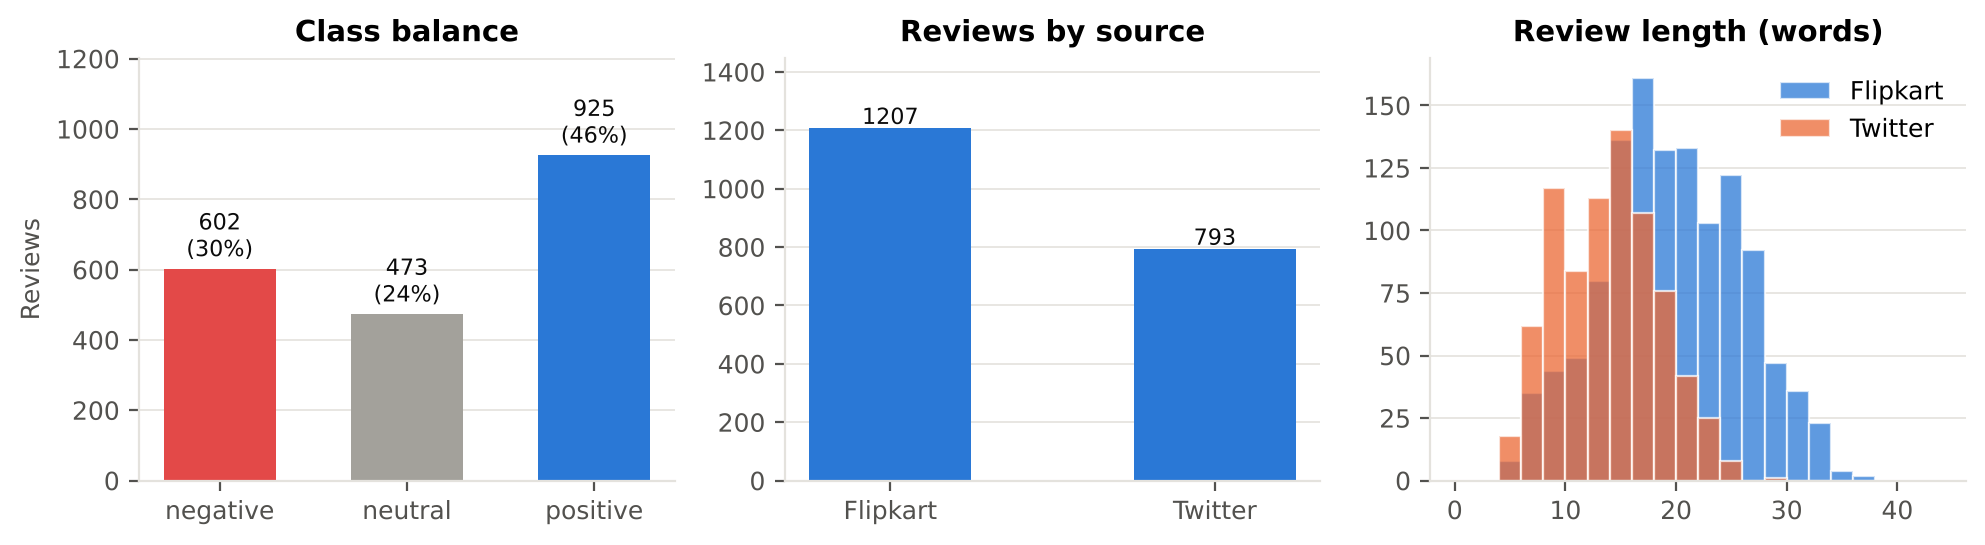

In [4]:
fig("fig01_eda.png")

Positive reviews are the largest class (46%), neutral the smallest (24%), so the data are moderately
imbalanced. That is why I use a **stratified** split and report **macro-F1** (which weights every class equally)
alongside the weighted metrics the brief asks for. Tweets are shorter than marketplace reviews.

### 1.2 Preprocessing
My cleaner differs from the class demo in four deliberate ways: negations and contrast words are kept,
contractions are expanded, emojis become sentiment tokens, and elongated words are shortened.

In [5]:
examples = ["@FlipkartSupport the jar quality is NOT worth the money!! #fail 😡 https://t.co/x1",
            "Can't fault the build quality, delivery wasn't slow either 😍",
            "sooo happy with it, veryyy good"]
pd.DataFrame({"raw": examples,
              "class-demo cleaning": [clean_text_demo(t) for t in examples],
              "my cleaning": [clean_text(t) for t in examples]})

,raw,class-demo cleaning,my cleaning
0,@FlipkartSupport the jar quality is NOT worth the money!! #fail 😡 https://t.co/x1,jar quality worth money fail,jar quality not worth money fail emo_neg
1,"Can't fault the build quality, delivery wasn't slow either 😍",cant fault build quality delivery wasnt slow either,not fault build quality delivery not slow either emo_pos
2,"sooo happy with it, veryyy good",sooo happy veryyy good,soo happy veryy good


In [6]:
df = sp.preprocess(df)
train, test = sp.split(df)
print("train:", len(train), " test:", len(test))
pd.concat([train.sentiment.value_counts(normalize=True).rename("train"),
           test.sentiment.value_counts(normalize=True).rename("test")], axis=1).round(3)

train: 1600  test: 400


,train,test
sentiment,,
positive,0.462,0.462
negative,0.301,0.300
neutral,0.236,0.238


### 1.3 Choosing TF-IDF settings (training data only, 5-fold CV)

In [7]:
grid, vocab, best = sp.tune_tfidf(train)
print("vocabulary size by n-gram range:", vocab)
print("best:", best)
grid.round(3)

vocabulary size by n-gram range: {'(1, 1)': 431, '(1, 2)': 2075, '(1, 3)': 4055}
best: {'tfidf__max_features': 2000, 'tfidf__ngram_range': (1, 2)}


max_features,500,1000,2000,5000,All
ngram_range,,,,,
"(1, 1)",0.946,0.946,0.946,0.946,0.946
"(1, 2)",0.932,0.943,0.947,0.947,0.947
"(1, 3)",0.904,0.932,0.928,0.929,0.929


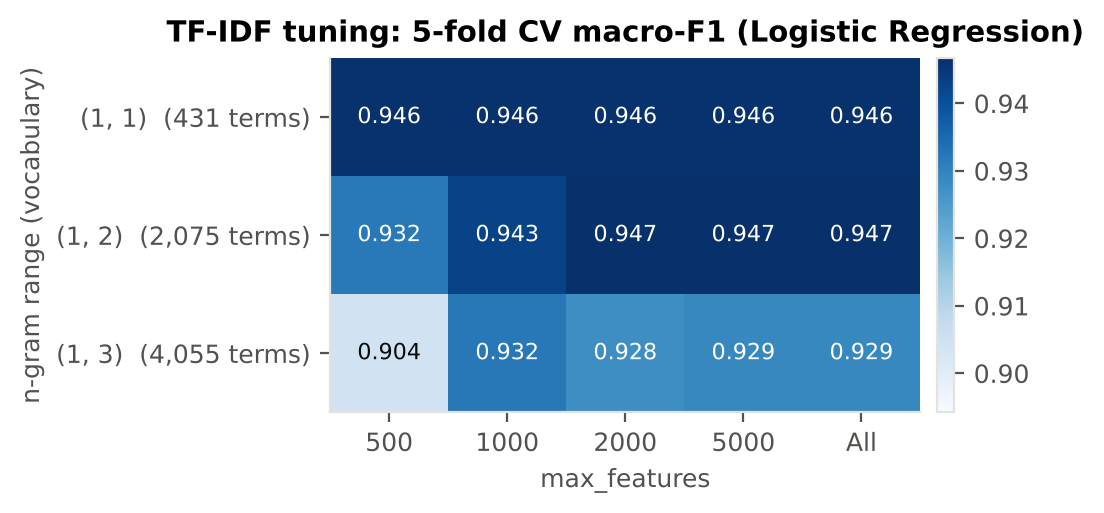

In [8]:
fig("fig02_tfidf_grid.png")

Bigrams (1,2) beat unigrams slightly because they keep phrases such as *not worth*, *very disappointed* and
*three stars*; trigrams add 2,000 mostly one-off terms and hurt. With `min_df=2` the full (1,2) vocabulary is
about 2,075 terms, so `max_features=2000` keeps essentially all of it at the same score while capping
dimensionality. **Chosen: `ngram_range=(1,2)`, `max_features=2000`, `sublinear_tf=True`, `min_df=2`.**

In [9]:
sp.preprocessing_ablation(train).round(4)

,Preprocessing,CV macro-F1,SD
0,Class-demo cleaning (standard stopwords),0.9327,0.0231
1,My cleaning (negations + emojis kept),0.9467,0.0190


Keeping negations and emojis raises cross-validated macro-F1 by about 1.4 points over the demo cleaner.

### 1.4 Train four classifiers
* **Logistic Regression**: linear, fast, interpretable coefficients, gives probabilities.
* **Multinomial Naive Bayes**: the classic text baseline; assumes word-count-like features.
* **Linear SVM**: max-margin linear model, usually the strongest with sparse high-dimensional TF-IDF.
* **Random Forest**: a non-linear ensemble, included to test whether word interactions help.

In [10]:
results, fitted, preds = sp.train_and_evaluate(train, test)
vader = sp.vader_baseline(test)

## 2. Evaluation and model comparison

In [11]:
show = pd.concat([results, pd.DataFrame([{k: v for k, v in vader.items() if k != "pred"}])], ignore_index=True)
show.round(3)

,Model,Accuracy,Precision,Recall,F1 (weighted),F1 (macro),CV macro-F1 (mean),CV macro-F1 (SD)
0,Linear SVM,0.960,0.960,0.960,0.960,0.954,0.961,0.019
1,Random Forest,0.945,0.945,0.945,0.945,0.939,0.933,0.020
2,Logistic Regression,0.935,0.935,0.935,0.934,0.928,0.947,0.019
3,Multinomial NB,0.902,0.902,0.902,0.902,0.890,0.899,0.026
4,VADER lexicon (baseline),0.658,0.649,0.658,0.644,0.610,NaN,NaN


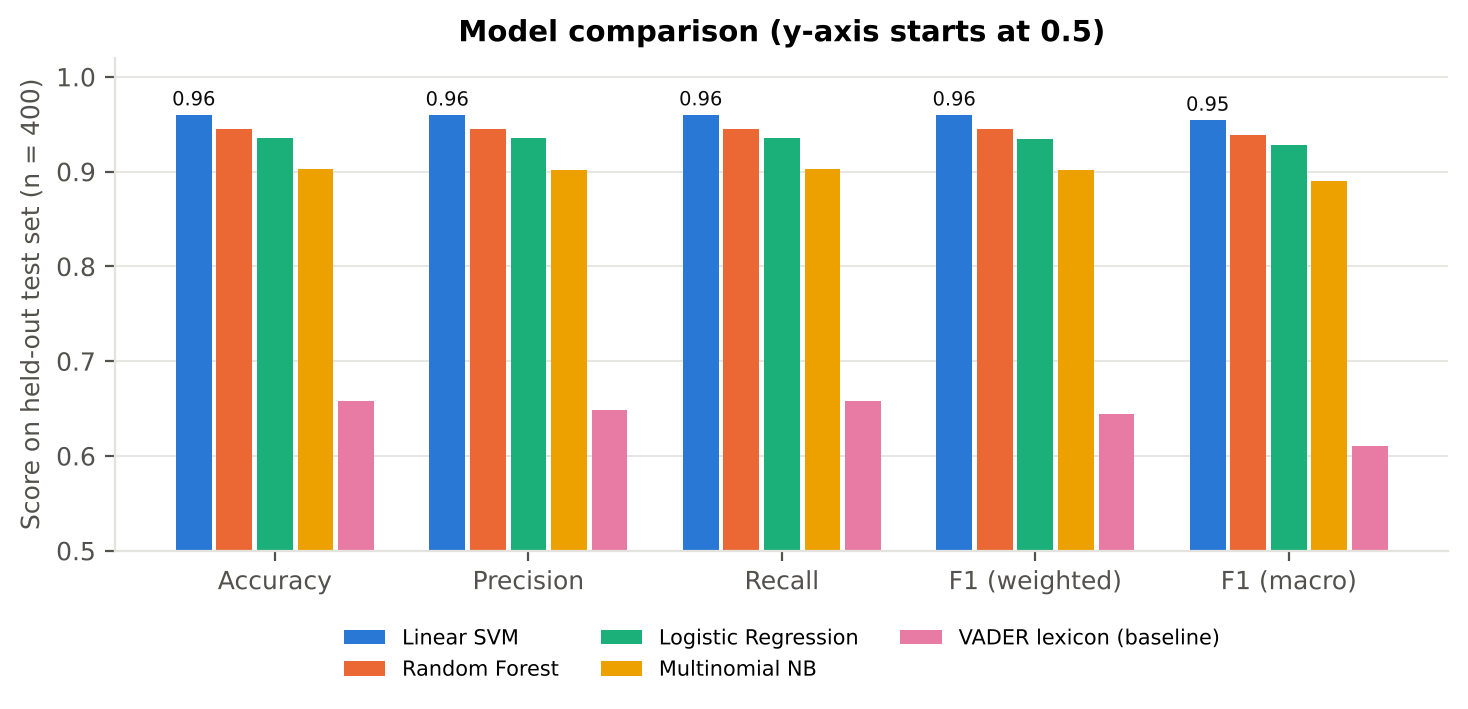

In [12]:
sp.plot_model_comparison(results, vader)
fig("fig03_model_comparison.png")

Best model: Linear SVM
              precision    recall  f1-score   support

    negative      0.975     0.975     0.975       120
     neutral      0.925     0.905     0.915        95
    positive      0.968     0.978     0.973       185

    accuracy                          0.960       400
   macro avg      0.956     0.953     0.954       400
weighted avg      0.960     0.960     0.960       400



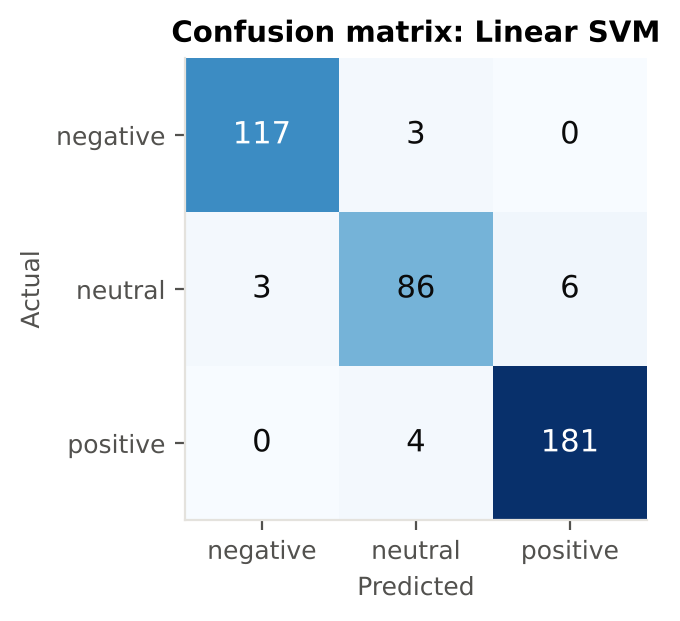

In [13]:
best_name = results.iloc[0]["Model"]
from sklearn.metrics import classification_report
print("Best model:", best_name)
print(classification_report(test["sentiment"], preds[best_name], digits=3))
cm = sp.plot_confusion(test, preds[best_name], best_name)
fig("fig04_confusion_matrix.png")

### 2.1 Error analysis
`pattern` is generator metadata (never used as a feature). It lets us see *what kind* of text the model gets
wrong, and compare with the VADER lexicon.

In [14]:
by_pattern, errors = sp.error_analysis(test, preds[best_name], vader["pred"])
by_pattern.round(3)

,n,accuracy,vader_accuracy
pattern,,,
noisy_label,11,0.000,0.273
negation,27,0.963,0.889
plain,243,0.984,0.745
mixed,79,1.000,0.532
sarcasm,12,1.000,0.000
wait_and_see,28,1.000,0.464


In [15]:
errors[["review_text", "pattern", "sentiment", "pred"]]

,review_text,pattern,sentiment,pred
300,Using this Nova 5G Smartphone for a month now. Delivery was rescheduled again and again. Support said a technician w...,plain,negative,neutral
634,the storage space has been flawless so far. https://t.co/yrsxxfmvdz,noisy_label,neutral,positive
916,Build quality is solid and reliable.,noisy_label,neutral,positive
1821,Second UrbanPack Laptop Backpack I have bought from this seller. Worth every penny. Requested an exchange for a diff...,plain,positive,neutral
1576,"Since the May update, the battery backup is not just good, it is great. Yes, really disappointed with the step and h...",noisy_label,neutral,positive
922,"Using this BlendPro Blender for a month now. The jar quality is not worth the money. Motor noise is fine, neither gr...",negation,negative,neutral
576,Using this PowerCore Power Bank for a month now. Delivery took the usual four to five days. Nothing more to add.,noisy_label,positive,neutral
1550,"Ordered the Nova 5G Smartphone for my brother. Battery life is solid and reliable, although the performance stopped ...",noisy_label,positive,neutral
1347,The delivery guy was very polite and on time. #unboxing 👍,noisy_label,neutral,positive
1615,@flipkartsupport the delivery person never showed up. #scam #disappointed,noisy_label,neutral,negative


In [16]:
sp.top_terms(fitted["Logistic Regression"])

,negative,neutral,positive
0,emo_neg,average,emo_pos
1,disappointed,although,happy
2,awful,balances,recommended
3,worstservice,emo_neu,go
4,very disappointed,average overall,honestly
5,not,three stars,five stars
6,seriously,okay,excellent
7,returning,overall,highly recommended


## 3. Sentiment trends

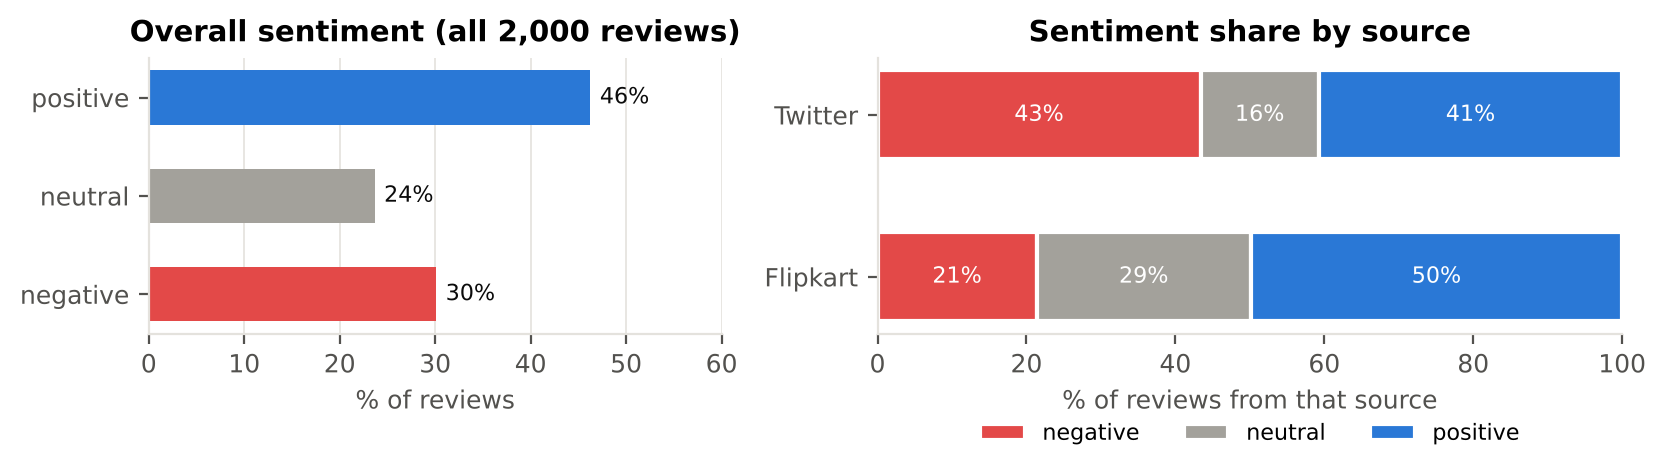

sentiment,negative,neutral,positive
source,,,
Flipkart,21.4,28.7,49.9
Twitter,43.4,15.9,40.7


In [17]:
share, by_source = sp.plot_distribution_by_source(df)
fig("fig05_distribution_by_source.png")
by_source.round(1)

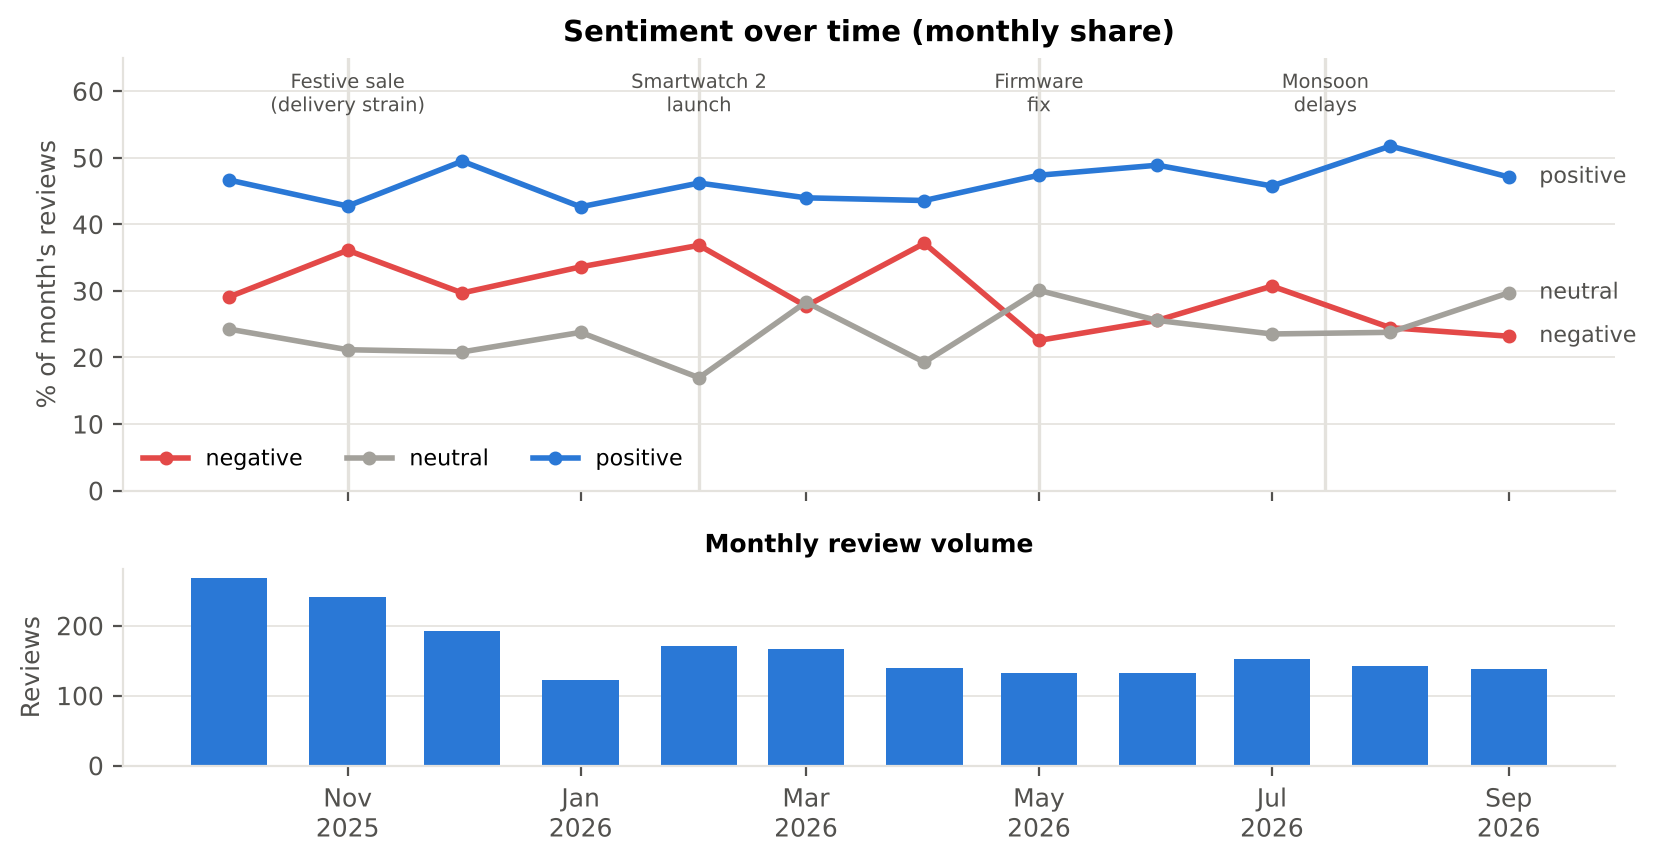

In [18]:
monthly, volume = sp.plot_time_trend(df)
fig("fig06_sentiment_over_time.png")

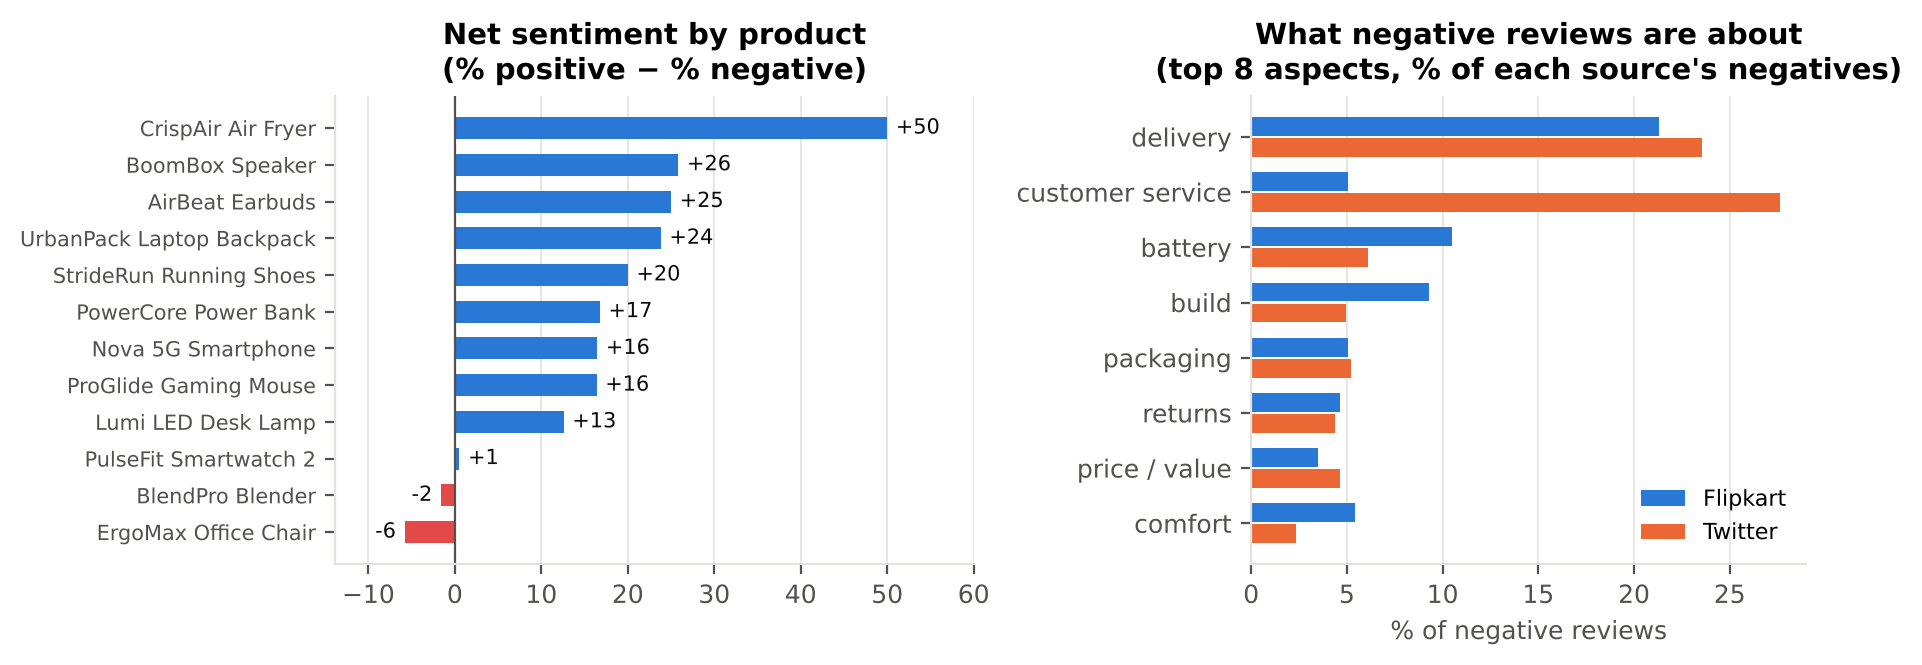

In [19]:
nss, aspects = sp.plot_products_and_aspects(df)
fig("fig07_products_and_aspects.png")

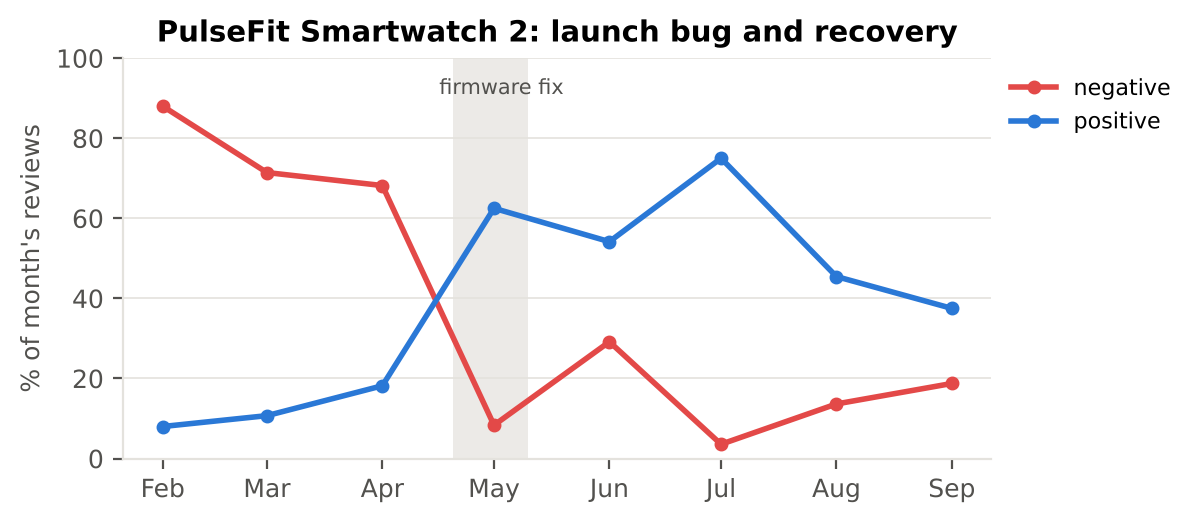

{'n': 189,
 'neg_before': np.float64(0.76),
 'neg_after': np.float64(0.14035087719298245),
 'nss_before': np.float64(-64.0),
 'nss_after': np.float64(42.98245614035088)}

In [20]:
sw = sp.plot_smartwatch(df)
fig("fig08_smartwatch_recovery.png")
sw

In [21]:
df.groupby("sentiment")["rating"].mean().round(2)   # star rating is a sanity check, not a feature

sentiment
negative    1.68
neutral     2.88
positive    4.32
Name: rating, dtype: float64

## 4. Robustness checks
**(a) Hand-written challenge set**: 36 reviews I wrote in phrasing the generator never uses.
**(b) The class sample file**: the same pipeline on `online_reviews_sentiment.csv`.

In [22]:
ch_results, ch = sp.challenge_set_eval(fitted)
ch_results.round(3)

,Model,Accuracy,F1 (macro)
0,Logistic Regression,0.500,0.495
1,Multinomial NB,0.500,0.508
2,Linear SVM,0.472,0.457
3,Random Forest,0.417,0.362
4,VADER lexicon (baseline),0.611,0.605


In [23]:
sp.class_sample_check(sp.DATA / "class_sample" / "online_reviews_sentiment.csv")

{'accuracy': 1.0, 'unique_texts': 497, 'n': 1000}

The models score 96% on the held-out synthetic test set but only about 42-50% on unseen real-style
phrasing, below the untrained VADER lexicon (61%). The class sample reaches 100% because it has only 497 unique
texts in 1,000 rows, so test sentences also appear in training. Both results show that a high test score on
template-based synthetic data mostly measures how well the model learned the templates. See the report for
the discussion.

## 5. Save the summary used in the report

In [24]:
summary = sp.main()   # re-runs everything end to end and writes outputs/tables/summary.json

              Model  Accuracy  Precision  Recall  F1 (weighted)  F1 (macro)  CV macro-F1 (mean)  CV macro-F1 (SD)
         Linear SVM     0.960      0.960   0.960          0.960       0.954               0.961             0.019
      Random Forest     0.945      0.945   0.945          0.945       0.939               0.933             0.020
Logistic Regression     0.935      0.935   0.935          0.934       0.928               0.947             0.019
     Multinomial NB     0.902      0.902   0.902          0.902       0.890               0.899             0.026
Best model: Linear SVM
